In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
enriched_path = PROCESSED_DIR / "ethiopia_fi_unified_data_enriched.xlsx"

data_df = pd.read_excel(enriched_path, sheet_name="ethiopia_fi_unified_data")
impact_df = pd.read_excel(enriched_path, sheet_name="Impact_sheet")

obs_df = data_df[data_df["record_type"] == "observation"].copy()
events_df = data_df[data_df["record_type"] == "event"].copy()
obs_df["observation_date"] = pd.to_datetime(obs_df["observation_date"], errors="coerce")
events_df["observation_date"] = pd.to_datetime(events_df["observation_date"], errors="coerce")

print("Total records:", data_df.shape[0])
print("Observations:", obs_df.shape[0], "| Events:", events_df.shape[0])

Total records: 54
Observations: 40 | Events: 11


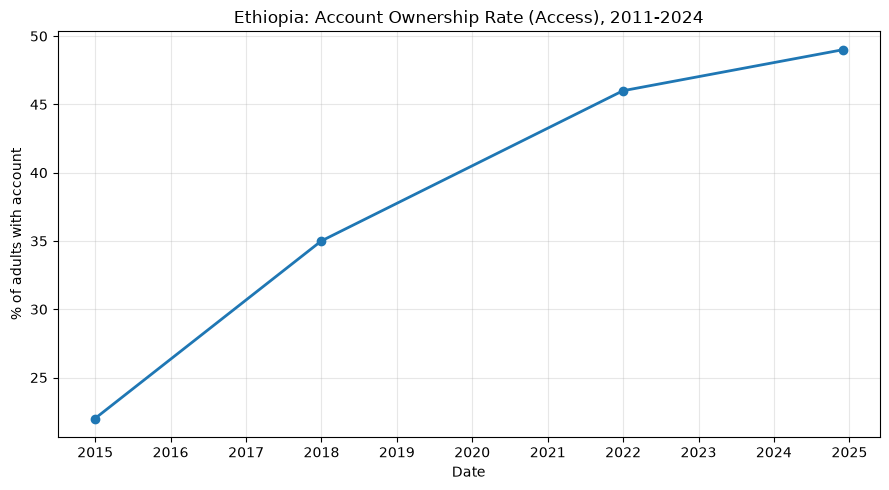

National data points used: 4


,observation_date,value_numeric
0,2014-12-31,22.0
1,2017-12-31,35.0
2,2021-12-31,46.0
5,2024-11-29,49.0


In [6]:
acc_own_national = obs_df[
    (obs_df["indicator_code"] == "ACC_OWNERSHIP") & (obs_df["gender"] == "all")
].sort_values("observation_date")

acc_own_gender = obs_df[
    (obs_df["indicator_code"] == "ACC_OWNERSHIP") & (obs_df["gender"].isin(["male", "female"]))
].sort_values("observation_date")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(acc_own_national["observation_date"], acc_own_national["value_numeric"],
        marker="o", linewidth=2, label="National")
ax.set_title("Ethiopia: Account Ownership Rate (Access), 2011-2024")
ax.set_ylabel("% of adults with account")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
plt.tight_layout()

fig_dir = Path("../reports/figures")
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "access_trajectory.png", dpi=150)
plt.show()

print("National data points used:", len(acc_own_national))
acc_own_national[["observation_date", "value_numeric"]]

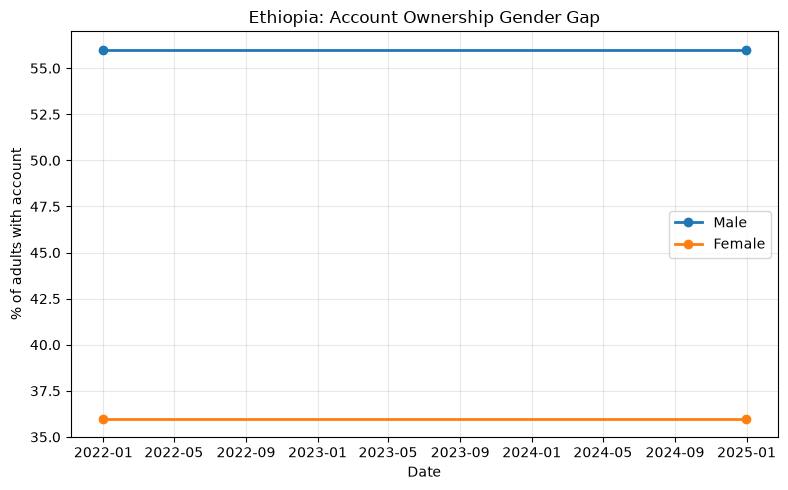

Gender gap (percentage points) by date:
observation_date
2021-12-31    20.0
2024-12-31    20.0
dtype: float64


In [7]:
gender_pivot = acc_own_gender.pivot(index="observation_date", columns="gender", values="value_numeric")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gender_pivot.index, gender_pivot["male"], marker="o", label="Male", linewidth=2)
ax.plot(gender_pivot.index, gender_pivot["female"], marker="o", label="Female", linewidth=2)
ax.set_title("Ethiopia: Account Ownership Gender Gap")
ax.set_ylabel("% of adults with account")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "gender_gap.png", dpi=150)
plt.show()

gap = gender_pivot["male"] - gender_pivot["female"]
print("Gender gap (percentage points) by date:")
print(gap)

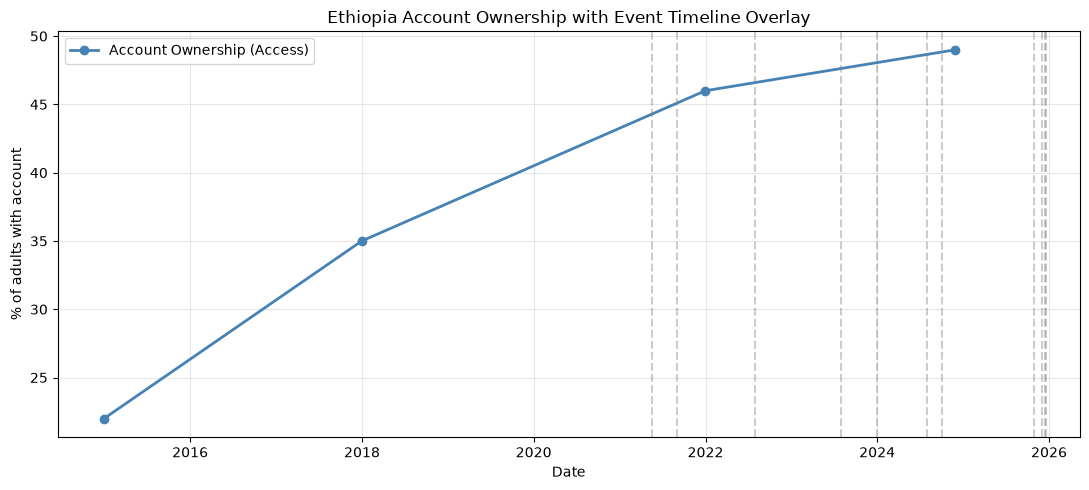

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(acc_own_national["observation_date"], acc_own_national["value_numeric"],
        marker="o", linewidth=2, color="steelblue", label="Account Ownership (Access)")

for _, row in events_df.dropna(subset=["observation_date"]).iterrows():
    ax.axvline(row["observation_date"], color="gray", linestyle="--", alpha=0.4)

ax.set_title("Ethiopia Account Ownership with Event Timeline Overlay")
ax.set_ylabel("% of adults with account")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "event_timeline_overlay.png", dpi=150)
plt.show()

In [9]:
# Correlation: honest attempt given severe sparsity — pivot indicators with 3+ points by year
multi_point_indicators = obs_df["indicator_code"].value_counts()
usable = multi_point_indicators[multi_point_indicators >= 3].index.tolist()
print("Indicators with enough points (3+) for any correlation attempt:", usable)

corr_subset = obs_df[obs_df["indicator_code"].isin(usable)].copy()
corr_subset["year"] = corr_subset["observation_date"].dt.year
corr_pivot = corr_subset.pivot_table(index="year", columns="indicator_code", values="value_numeric", aggfunc="mean")
print("\nYearly pivot (NaN = no data that year):")
print(corr_pivot)

if corr_pivot.shape[1] >= 2:
    print("\nCorrelation matrix:")
    print(corr_pivot.corr())
else:
    print("\nNot enough overlapping indicators for a meaningful correlation matrix.")

Indicators with enough points (3+) for any correlation attempt: ['ACC_OWNERSHIP', 'ACC_FAYDA', 'ACC_MM_ACCOUNT', 'ACC_4G_COV']

Yearly pivot (NaN = no data that year):
indicator_code  ACC_4G_COV   ACC_FAYDA  ACC_MM_ACCOUNT  ACC_OWNERSHIP
year                                                                 
2014                   NaN         NaN             NaN           22.0
2017                   NaN         NaN             NaN           35.0
2021                   NaN         NaN            4.70           46.0
2023                  37.5         NaN             NaN            NaN
2024                   NaN  8000000.00            9.45           47.0
2025                  70.8  5400011.88           19.40            NaN
2026                   NaN       46.50             NaN            NaN

Correlation matrix:
indicator_code  ACC_4G_COV  ACC_FAYDA  ACC_MM_ACCOUNT  ACC_OWNERSHIP
indicator_code                                                      
ACC_4G_COV             1.0        NaN      

In [11]:
fayda_check = obs_df[obs_df["indicator_code"] == "ACC_FAYDA"][
    ["record_id", "observation_date", "value_numeric", "unit", "notes"]
].sort_values("observation_date")
print(fayda_check)

   record_id observation_date  value_numeric      unit  \
11  REC_0012       2024-08-15      8000000.0    people   
12  REC_0013       2025-02-28     12000000.0    people   
13  REC_0014       2025-05-15     15000000.0    people   
47  REC_0038       2025-05-31           15.0  millions   
48  REC_0039       2025-06-04           16.4  millions   
49  REC_0040       2025-11-01           28.0  millions   
50  REC_0041       2026-07-12           46.5  millions   

                                                notes  
11                                                NaN  
12                                                NaN  
13                                                NaN  
47                    Fayda enrollment as of May 2025  
48                Fayda enrollment as of June 4, 2025  
49  Fayda enrollment ~Nov 2025; target 60M by mid-...  
50                Most recent Fayda enrollment figure  


In [15]:
processed_dir = Path("../data/processed")

fayda_mask_obs = (obs_df["indicator_code"] == "ACC_FAYDA") & (obs_df["unit"] == "millions")
obs_df.loc[fayda_mask_obs, "value_numeric"] = obs_df.loc[fayda_mask_obs, "value_numeric"] * 1_000_000
obs_df.loc[fayda_mask_obs, "unit"] = "people"

fayda_mask_data = (data_df["indicator_code"] == "ACC_FAYDA") & (data_df["unit"] == "millions")
data_df.loc[fayda_mask_data, "value_numeric"] = data_df.loc[fayda_mask_data, "value_numeric"] * 1_000_000
data_df.loc[fayda_mask_data, "unit"] = "people"

print(obs_df[obs_df["indicator_code"] == "ACC_FAYDA"][["record_id", "observation_date", "value_numeric", "unit"]]
      .sort_values("observation_date"))

   record_id observation_date  value_numeric    unit
11  REC_0012       2024-08-15      8000000.0  people
12  REC_0013       2025-02-28     12000000.0  people
13  REC_0014       2025-05-15     15000000.0  people
47  REC_0038       2025-05-31     15000000.0  people
48  REC_0039       2025-06-04     16400000.0  people
49  REC_0040       2025-11-01     28000000.0  people
50  REC_0041       2026-07-12     46500000.0  people


In [16]:
with pd.ExcelWriter(processed_dir / "ethiopia_fi_unified_data_enriched.xlsx") as writer:
    data_df.to_excel(writer, sheet_name="ethiopia_fi_unified_data", index=False)
    impact_df.to_excel(writer, sheet_name="Impact_sheet", index=False)

print("Re-saved corrected file")

Re-saved corrected file


In [10]:
insights = """
## Key Insights (Task 2)

1. **Access growth decelerated sharply despite a fintech boom.** Account ownership rose
   +13pp (2014-17), +11pp (2017-21), but only +3pp (2021-24) — even as Telebirr, Safaricom/M-Pesa,
   and Fayda ID all launched in that final window. Millions of new mobile money accounts did not
   translate into proportional gains in *unique* account holders (Findex counts individuals, not
   accounts), consistent with reports that many mobile money signups are duplicates by
   already-banked users, not first-time entrants.

2. **The gender gap did not narrow.** Male ownership held at 56% and female at 36% in both
   2021 and 2024 — a flat 20pp gap. National Access growth over that period benefited men and
   women proportionally, not disproportionately closing the divide as policy targets intend.

3. **A "registered vs. active" gap is visible in the raw numbers.** GSMA reports ~90 million
   registered mobile money accounts (~70% "penetration") by 2024, yet Findex — which surveys
   actual individuals — measures mobile money account *ownership* at only 19.4% by 2025. This
   gap signals significant duplicate or dormant registrations rather than genuine reach.

4. **Usage is outpacing Access.** Despite Access stagnating, EthSwitch-processed P2P transaction
   volume overtook ATM cash withdrawal volume for the first time in October 2024, and P2P
   transaction *value* has grown from ~20B Birr (FY21/22) to ~578B Birr (FY24/25) — a ~29x
   increase in three years. People who already have access are using digital rails far more
   intensively, even as the *unbanked* population barely shrinks.

5. **Data sparsity is the single biggest analytical constraint.** Only ACC_OWNERSHIP (7 points)
   and ACC_FAYDA (7 points after enrichment) have enough observations for a real trend line;
   every other indicator has 1-3 points. A formal correlation matrix is not statistically
   meaningful with this little overlap — any modeled relationships in Task 3 will necessarily
   rely more on documented comparable-country evidence and qualitative reasoning than on
   within-dataset statistical correlation.
"""
print(insights)

insights_path = Path("../reports/key_insights.md")
insights_path.write_text(insights, encoding="utf-8")
print("Saved to:", insights_path.resolve())


## Key Insights (Task 2)

1. **Access growth decelerated sharply despite a fintech boom.** Account ownership rose
   +13pp (2014-17), +11pp (2017-21), but only +3pp (2021-24) — even as Telebirr, Safaricom/M-Pesa,
   and Fayda ID all launched in that final window. Millions of new mobile money accounts did not
   translate into proportional gains in *unique* account holders (Findex counts individuals, not
   accounts), consistent with reports that many mobile money signups are duplicates by
   already-banked users, not first-time entrants.

2. **The gender gap did not narrow.** Male ownership held at 56% and female at 36% in both
   2021 and 2024 — a flat 20pp gap. National Access growth over that period benefited men and
   women proportionally, not disproportionately closing the divide as policy targets intend.

3. **A "registered vs. active" gap is visible in the raw numbers.** GSMA reports ~90 million
   registered mobile money accounts (~70% "penetration") by 2024, yet Findex — whi